# The Kaiser-Bessel Gridding Kernel in 1D and 2D

This notebook visualises the Kaiser-Bessel (KB) convolution kernel used by
`grid_visibilities_conv` / `degrid_visibilities_conv` in `argosim.imaging_utils`.

**Recap of how gridding works.** Each visibility sits at a *continuous* pixel
position `(u, v)`. Convolutional gridding spreads it over the `W x W` block of
grid pixels centred on the nearest pixel `(u0, v0)`. The weight given to grid
pixel `(iu, iv)` is

$$ w(iu, iv) = \mathrm{KB}(u - iu)\; \mathrm{KB}(v - iv), $$

i.e. a **single 1D KB filter centred on the visibility, sampled at the integer
pixel centres**, in each axis separately. The 2D kernel is the *outer product*
of the two 1D kernels (the KB window is separable).

Sections:
1. The 1D KB kernel
2. The 2D KB kernel as an outer product (image + surface)
3. Sampling the kernel at integer pixels for an on-pixel vs. sub-pixel visibility
4. Cross-check: the 2D kernel equals a single gridded point source

In [2]:
import jax
jax.config.update("jax_enable_x64", True)  # double precision

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)

from argosim.imaging_utils import kaiser_bessel, grid_visibilities_conv

plt.rcParams["figure.dpi"] = 100

# Kernel parameters (same defaults as simulate_dirty_observation)
W = 7               # support width in pixels (odd)
beta = 2.34 * W     # KB shape parameter
print(f"W = {W}, beta = {beta:.3f}")

W = 7, beta = 16.380


## 1. The 1D KB kernel

The kernel is defined for `x` in `[-W/2, W/2]` and clipped to zero outside.
It peaks at `x = 0` (value 1) and tapers smoothly to the support edges.

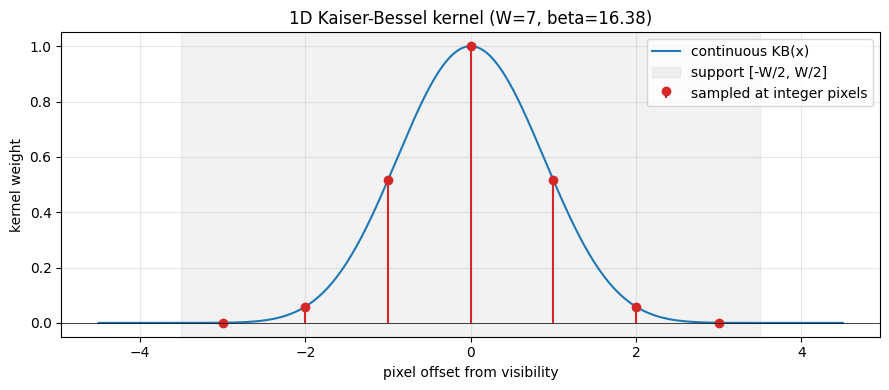

Weights an on-pixel visibility deposits on its 7 neighbours:
[5.000e-04 5.860e-02 5.163e-01 1.000e+00 5.163e-01 5.860e-02 5.000e-04]


In [3]:
x = jnp.linspace(-W / 2 - 1, W / 2 + 1, 1000)
k = kaiser_bessel(x, W, beta)

# Integer pixel offsets that a single visibility actually touches: -W//2 .. W//2
half_W = W // 2
x_int = np.arange(-half_W, half_W + 1)
k_int = np.array(kaiser_bessel(jnp.array(x_int, dtype=float), W, beta))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.array(x), np.array(k), color="C0", label="continuous KB(x)")
ax.stem(x_int, k_int, linefmt="C3-", markerfmt="C3o", basefmt=" ",
        label="sampled at integer pixels")
ax.axvspan(-W / 2, W / 2, color="gray", alpha=0.1, label="support [-W/2, W/2]")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("pixel offset from visibility")
ax.set_ylabel("kernel weight")
ax.set_title(f"1D Kaiser-Bessel kernel (W={W}, beta={beta:.2f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Weights an on-pixel visibility deposits on its", W, "neighbours:")
print(np.round(k_int, 4))

## 2. The 2D KB kernel = outer product of two 1D kernels

The 2D weight applied to the `W x W` block is `KB(du) * KB(dv)`. Because the
kernel is separable, we can build the full 2D kernel as the outer product of a
1D kernel with itself. Below is a smooth, finely-sampled version so the shape is
clear.

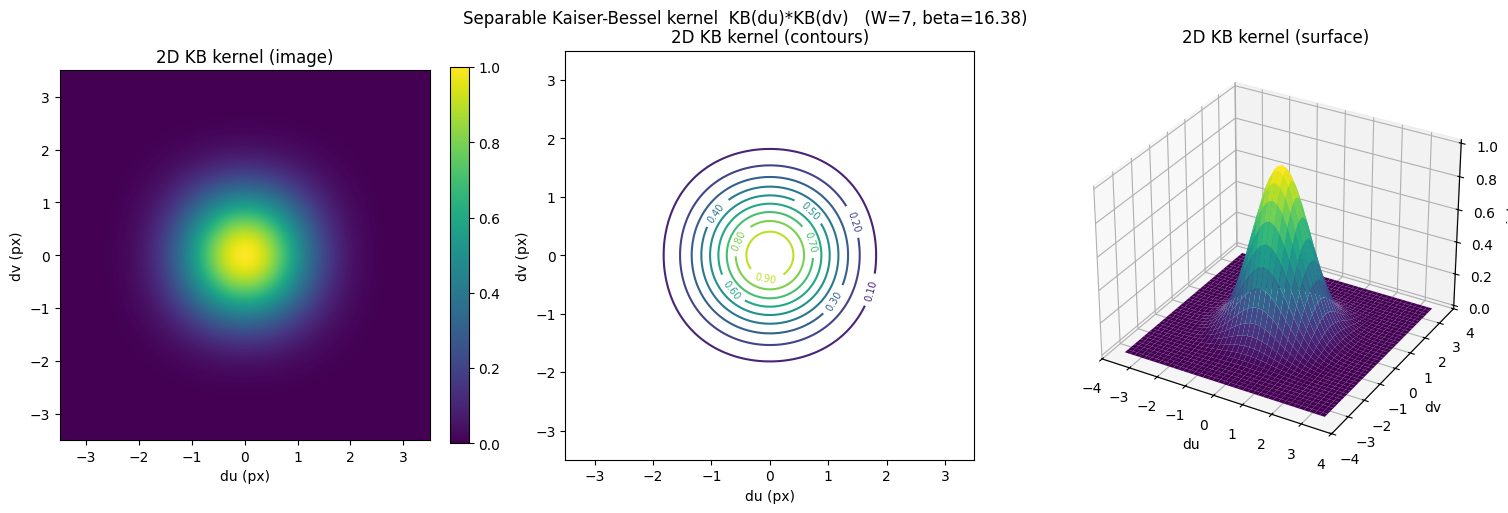

In [4]:
# Fine grid over the support for a smooth picture of the 2D kernel
n = 201
g = jnp.linspace(-W / 2, W / 2, n)
kb_1d = kaiser_bessel(g, W, beta)
kb_2d = jnp.outer(kb_1d, kb_1d)          # separable: KB(u) * KB(v)
kb_2d_np = np.array(kb_2d)
gg = np.array(g)

fig = plt.figure(figsize=(15, 5))

# (a) top-down image
ax0 = fig.add_subplot(1, 3, 1)
im = ax0.imshow(kb_2d_np, origin="lower", cmap="viridis",
                extent=[gg[0], gg[-1], gg[0], gg[-1]])
plt.colorbar(im, ax=ax0, fraction=0.046)
ax0.set_title("2D KB kernel (image)")
ax0.set_xlabel("du (px)"); ax0.set_ylabel("dv (px)")

# (b) contour
ax1 = fig.add_subplot(1, 3, 2)
cs = ax1.contour(gg, gg, kb_2d_np, levels=10, cmap="viridis")
ax1.clabel(cs, inline=True, fontsize=7, fmt="%.2f")
ax1.set_aspect("equal")
ax1.set_title("2D KB kernel (contours)")
ax1.set_xlabel("du (px)"); ax1.set_ylabel("dv (px)")

# (c) 3D surface
ax2 = fig.add_subplot(1, 3, 3, projection="3d")
U, V = np.meshgrid(gg, gg)
ax2.plot_surface(U, V, kb_2d_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("2D KB kernel (surface)")
ax2.set_xlabel("du"); ax2.set_ylabel("dv"); ax2.set_zlabel("weight")

plt.suptitle(f"Separable Kaiser-Bessel kernel  KB(du)*KB(dv)   (W={W}, beta={beta:.2f})")
plt.tight_layout()
plt.show()

## 3. What a visibility actually deposits: integer-pixel weights

In practice the kernel is only ever evaluated at the `W x W` **integer** pixel
offsets. For a visibility sitting exactly on a pixel centre the weights are
symmetric; for a sub-pixel visibility the whole kernel shifts, so the sampled
weights become asymmetric. That asymmetry is precisely what carries the
sub-pixel position information onto the grid.

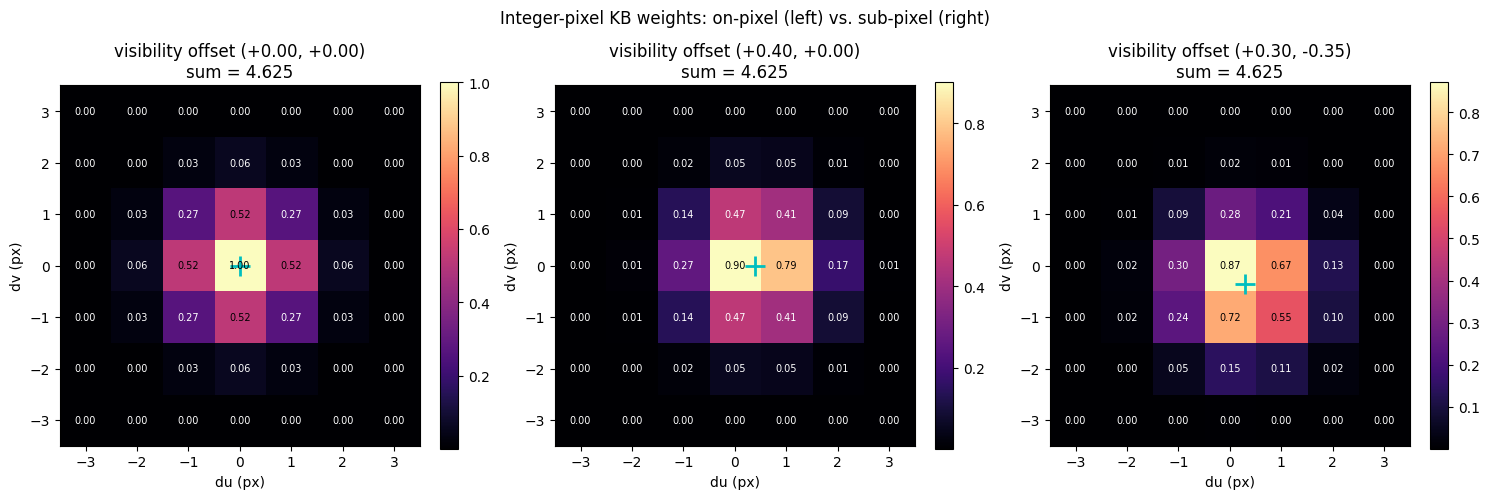

In [5]:
def kernel_weights_2d(frac_u, frac_v):
    """W x W integer-pixel weights for a visibility at sub-pixel offset (frac_u, frac_v).

    frac_u, frac_v are the offsets of the true position from the nearest pixel
    centre, each in [-0.5, 0.5]. Returns the (W, W) weight block, rows = dv.
    """
    du = np.arange(-half_W, half_W + 1)
    ku = np.array(kaiser_bessel(jnp.array(frac_u - du, dtype=float), W, beta))
    kv = np.array(kaiser_bessel(jnp.array(frac_v - du, dtype=float), W, beta))
    return np.outer(kv, ku)  # rows indexed by dv, cols by du

cases = [(0.0, 0.0), (0.4, 0.0), (0.3, -0.35)]
fig, axes = plt.subplots(1, len(cases), figsize=(15, 5))
for ax, (fu, fv) in zip(axes, cases):
    w = kernel_weights_2d(fu, fv)
    im = ax.imshow(w, origin="lower", cmap="magma",
                   extent=[-half_W - 0.5, half_W + 0.5, -half_W - 0.5, half_W + 0.5])
    plt.colorbar(im, ax=ax, fraction=0.046)
    # mark the true sub-pixel visibility position
    ax.plot(fu, fv, "c+", markersize=14, markeredgewidth=2)
    # annotate each pixel with its weight
    for i, dv in enumerate(range(-half_W, half_W + 1)):
        for j, du in enumerate(range(-half_W, half_W + 1)):
            ax.text(du, dv, f"{w[i, j]:.2f}", ha="center", va="center",
                    color="white" if w[i, j] < 0.5 else "black", fontsize=7)
    ax.set_title(f"visibility offset ({fu:+.2f}, {fv:+.2f})\nsum = {w.sum():.3f}")
    ax.set_xlabel("du (px)"); ax.set_ylabel("dv (px)")
plt.suptitle("Integer-pixel KB weights: on-pixel (left) vs. sub-pixel (right)")
plt.tight_layout()
plt.show()

## 4. Cross-check against `grid_visibilities_conv`

Gridding a single unit visibility must reproduce exactly the `W x W` weight
block we drew by hand. We place one visibility at a sub-pixel position on a
small grid and compare the non-zero footprint against `kernel_weights_2d`.

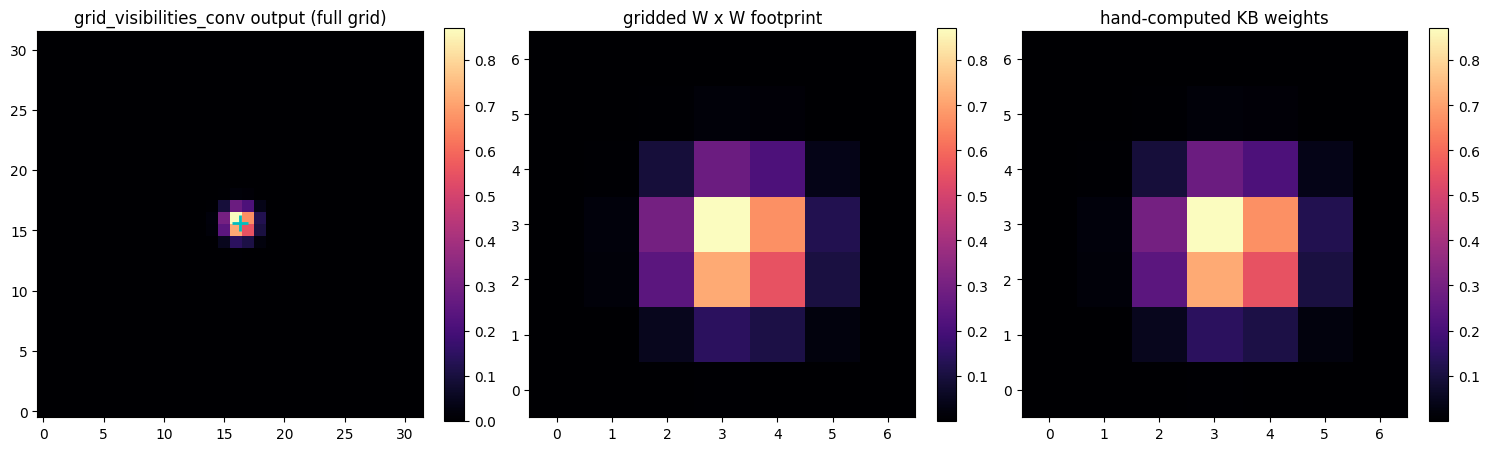

Max abs difference (gridded vs. hand-computed): 3.1086244689504383e-15
-> the two agree to machine precision.


In [6]:
grid_shape = (32, 32)
u0, v0 = 16, 16              # nearest pixel
frac_u, frac_v = 0.3, -0.35  # sub-pixel offset
uv_px = jnp.array([[u0 + frac_u, v0 + frac_v]])
vis = jnp.array([1.0 + 0j])

grid = np.array(grid_visibilities_conv(vis, uv_px, grid_shape, W, beta)).real

# Extract the W x W footprint around the nearest pixel
block = grid[v0 - half_W: v0 + half_W + 1, u0 - half_W: u0 + half_W + 1]
expected = kernel_weights_2d(frac_u, frac_v)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].imshow(grid, origin="lower", cmap="magma")
plt.colorbar(im0, ax=axes[0], fraction=0.046)
axes[0].plot(u0 + frac_u, v0 + frac_v, "c+", markersize=12, markeredgewidth=2)
axes[0].set_title("grid_visibilities_conv output (full grid)")

im1 = axes[1].imshow(block, origin="lower", cmap="magma")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[1].set_title("gridded W x W footprint")

im2 = axes[2].imshow(expected, origin="lower", cmap="magma")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
axes[2].set_title("hand-computed KB weights")
plt.tight_layout()
plt.show()

print("Max abs difference (gridded vs. hand-computed):",
      float(np.max(np.abs(block - expected))))
print("-> the two agree to machine precision.")

## 5. Side-by-side: nearest-neighbour vs. convolutional gridding

A single visibility gridded three ways, zoomed so individual grid pixels are
visible. **Left:** nearest-neighbour gridding dumps the entire visibility onto
the single closest pixel (the old binary/histogram behaviour). **Middle:**
convolutional gridding spreads it over the W x W block with Kaiser-Bessel
weights, shifted toward the true sub-pixel position (cyan +). **Right:** the
2D KB kernel surface that defines those weights.

/var/folders/9y/7z0g8qdn2bvc23npg8q10qxn7rzw1x/T/ipykernel_17262/2929868115.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9y/7z0g8qdn2bvc23npg8q10qxn7rzw1x/T/ipykernel_17262/2929868115.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


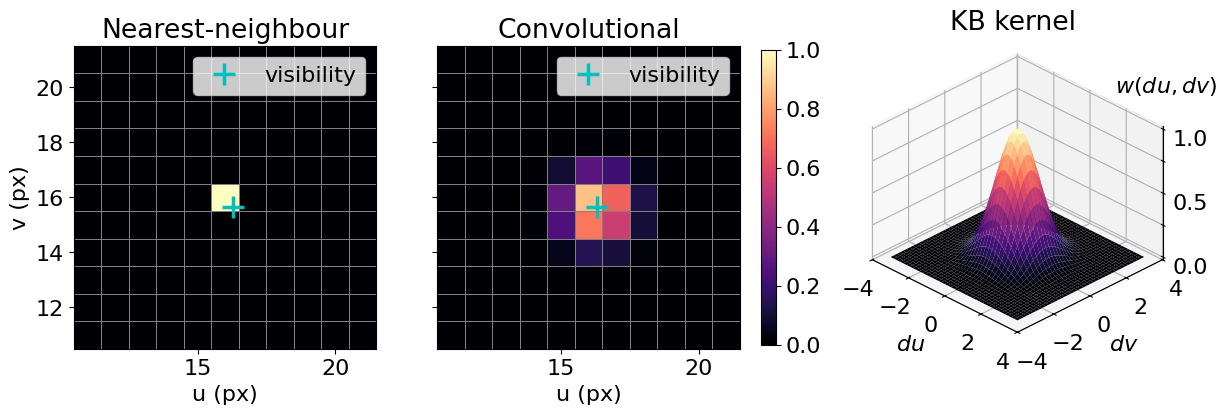

In [129]:
plt.rcParams["font.size"] = 16
# ---- Three-panel figure: NN gridding | convolutional gridding | KB surface ----
grid_shape = (32, 32)
u0, v0 = 16, 16               # nearest pixel
frac_u, frac_v = 0.3, -0.35   # sub-pixel offset of the true visibility
u_true, v_true = u0 + frac_u, v0 + frac_v

# Nearest-neighbour gridding: snap to nearest pixel, deposit the full weight there
grid_nn = np.zeros(grid_shape)
grid_nn[int(round(v_true)), int(round(u_true))] = 1.0

# Convolutional (KB) gridding of the same single unit visibility
grid_conv = np.array(grid_visibilities_conv(
    jnp.array([1.0 + 0j]), jnp.array([[u_true, v_true]]), grid_shape, W, beta)).real

# Zoom window and pixel-edge coordinates (pcolormesh draws pixel boundaries)
r = 5
sl = (slice(v0 - r, v0 + r + 1), slice(u0 - r, u0 + r + 1))
u_edges = np.arange(u0 - r, u0 + r + 2) - 0.5
v_edges = np.arange(v0 - r, v0 + r + 2) - 0.5

fig = plt.figure(figsize=(14, 5))

# Panel 1: nearest-neighbour
ax0 = fig.add_subplot(1, 3, 1)
pc0 = ax0.pcolormesh(u_edges, v_edges, grid_nn[sl], cmap="magma", vmin=0, vmax=1,
                     edgecolors="gray", linewidth=0.5)
# plt.colorbar(pc0, ax=ax0, fraction=0.046)
ax0.plot(u_true, v_true, "c+", markersize=16, markeredgewidth=2.5, label="visibility")
ax0.set_aspect("equal")
# ax0.set_title("Nearest-neighbour gridding\n(all weight on 1 pixel)")
ax0.set_title("Nearest-neighbour")
ax0.set_xlabel("u (px)"); ax0.set_ylabel("v (px)"); ax0.legend(loc="upper right")

# Panel 2: convolutional (KB)
ax1 = fig.add_subplot(1, 3, 2)
pc1 = ax1.pcolormesh(u_edges, v_edges, grid_conv[sl], cmap="magma", vmin=0, vmax=1,
                     edgecolors="gray", linewidth=0.5)
# plt.colorbar(pc1, ax=ax1, fraction=0.046)
ax1.plot(u_true, v_true, "c+", markersize=16, markeredgewidth=2.5, label="visibility")
ax1.set_aspect("equal")
ax1.set_title(f"Convolutional")
# ax1.set_title(f"Convolutional gridding (KB, W={W})\n(spread over W x W pixels)")
ax1.set_xlabel("u (px)"); 
# ax1.set_ylabel("v (px)"); 
ax1.set_yticklabels([])  # hide y-tick labels to avoid clutter
ax1.legend(loc="upper right")

fig.colorbar(pc1, ax=[ax0, ax1], fraction=0.021, pad=0.03)

# Panel 3: KB kernel surface
ax2 = fig.add_subplot(1, 3, 3, projection="3d")
g = jnp.linspace(-W / 2, W / 2, 201)
kb_1d = kaiser_bessel(g, W, beta)
kb_2d = np.array(jnp.outer(kb_1d, kb_1d))
gg = np.array(g)
U, V = np.meshgrid(gg, gg)
ax2.plot_surface(U, V, kb_2d, cmap="magma", linewidth=0, antialiased=True)
# ax2.set_title("KB kernel surface\nKB(du) * KB(dv)")
ax2.set_title("KB kernel")
ax2.set_xlabel(r"$du$", labelpad=7); ax2.set_ylabel(r"$dv$", labelpad=7); 
ax2.set_zlabel("")                       # remove the default (croppable) z-label
ax2.text2D(0.98, 0.85, r"$w(du,dv)$",         # place it manually instead
             transform=ax2.transAxes, ha="center", va="center")
ax2.view_init(elev=30, azim=-45)
ax2.set_zticks([0, 0.25 ,0.5, 0.75, 1.0], ["0.0", "", "0.5", "", "1.0"])  # manual z-ticks
ax2.set_proj_type("ortho")

pos = ax2.get_position()
ax2.set_position([pos.x0 + 0.01, pos.y0, pos.width, pos.height])

# plt.suptitle("Single-visibility gridding: nearest-neighbour vs. convolutional (KB)")
plt.tight_layout()


plt.savefig("array_optim/figs/NN_vs_KB_gridding.pdf")